# 2025 Tariff announcement - Exploratory data analysis

## 1. Load packages

In [10]:
# Install Reactable if not yet installed
#!pip install reactable

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Import Reactable and features
from reactable import Reactable, embed_css, Column

# Webscrapping
import requests
from bs4 import BeautifulSoup
from IPython.display import Image, display # this is needed for the display of the image loaded directly from scraped page

## 2. Load and inspect tariff data

In [23]:
# Specify the path to your Excel file
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/CEMFI/Summer School and Short Courses/Data Science/Codes/Trump tariffs.xlsx"

# Read the Excel file into a DataFrame
tariff_data = pd.read_excel(file_path)

# Display the first few rows of the DataFrame
#print(tariff_data.head())

# Display the DataFrame
tariff_data

,Country,Tariffs Charged to the U.S.A. (%),U.S.A. Discounted Reciprocal Tariffs (%)
0,China,67,34
1,European Union,39,20
2,Vietnam,90,46
3,Taiwan,64,32
4,Japan,46,24
...,...,...,...
180,Tokelau,10,10
181,Guinea-Bissau,10,10
182,Svalbard and Jan Mayen,10,10
183,Heard and McDonald Islands,10,10


### Make an interactive table using Reactable

In [19]:
# Note that currently this function is required to put css into notebooks.
embed_css()

# Create and display the interactive table that includes a search option
Reactable(
    tariff_data,
    columns=[
        Column(id='Country"', filterable=True),  # Enable filtering for 'Country' column
        Column(id='Tariffs Charged to the U.S.A. (%)', filterable=True),        # To disable filtering for 'tariff' column, set to False
        Column(id='U.S.A. Discounted Reciprocal Tariffs (%)', filterable=True),  # To disable filtering for 'tariff' column, set to False
    ],
    default_page_size=15,
    searchable=True,
    filterable=True,
)

ReactableWidget(props={'data': {'Country': ['China', 'European Union', 'Vietnam', 'Taiwan', 'Japan', 'India', …

## 3. Descriptive Statistics

### Summary Statistics Table

In [28]:
tariff_data[['Tariffs Charged to the U.S.A. (%)', 'U.S.A. Discounted Reciprocal Tariffs (%)']].describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
Tariffs Charged to the U.S.A. (%),185.0,26.1622,25.6406,10.0,10.0,10.0,39.0,99.0
U.S.A. Discounted Reciprocal Tariffs (%),185.0,16.2865,10.9901,10.0,10.0,10.0,18.0,50.0


The original tariffs charged to the U.S. are highly dispersed, with a long right tail and several countries imposing extremely high rates (up to 99%). In contrast, the U.S. reciprocal tariff schedule is more compressed, with most countries receiving the minimum 10% rate and a maximum of 50%. This suggests the new tariff structure reduces extreme variation and clusters most countries into lower bands.

### Box plot

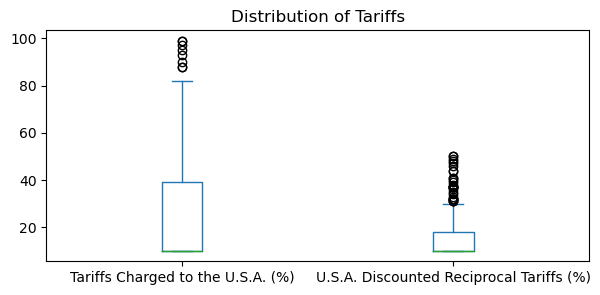

In [39]:
tariff_data[
    ['Tariffs Charged to the U.S.A. (%)',
     'U.S.A. Discounted Reciprocal Tariffs (%)']
].plot(kind='box', figsize=(7,3), title='Distribution of Tariffs')
plt.show()

The boxplot shows that tariffs charged to the U.S. are widely dispersed with several high outliers, while the U.S. reciprocal tariffs are much more compressed around the 10–20% range. 

## 4. Distribution of Tariffs

### Share of Countries by Tariff Range

In [57]:
# Count total number of countries slapped with tariffs
N_total = len(tariff_data)

# Share of countries with the 10% tariff rate
N_10pct = (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] == 10).sum()
share_10pct = N_10pct/N_total * 100
print("Share of countries with 10% tariff:", round(share_10pct,2), "% \n")

Share of countries with 10% tariff: 67.57 % 



In [61]:
## Share of countries with different ranges of tariffs
# Define the ranges as tuples (lower_bound, upper_bound)
ranges = [(0, 10), (10, 20), (20, 30), (30, 40), (40, 50)]

# Initialize a dictionary to store the shares
range_shares = {}

# Iterate over each range and count the rows
for lower, upper in ranges:
    count = ((tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] > lower) & 
            (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] <= upper)).sum()
    share = round(count/N_total * 100,2)

    # For display purposes (store values in range_shares): 
    # If upper = 10%, don't display the 0-10% range. Display only 10% since that is the minimum reciprocal tariff.
    # For all the rest, display the range
    if upper == 10:
        range_shares[f'{upper}%'] = share
    else:
        range_shares[f'{lower}-{upper}%'] = share

# Display the shares
for range_str, shares in range_shares.items():
    if range_str == '10%':
        print(f'Share of countries with tariffs = {range_str}: {shares}%')
    else:
        print(f'Share of countries with tariffs between {range_str}: {shares}%')

Share of countries with tariffs = 10%: 67.57%
Share of countries with tariffs between 10-20%: 8.65%
Share of countries with tariffs between 20-30%: 8.11%
Share of countries with tariffs between 30-40%: 10.27%
Share of countries with tariffs between 40-50%: 5.41%


In [66]:
range_df = pd.DataFrame.from_dict(
    range_shares, 
    orient='index', 
    columns=['Share of countries (%)']
)

range_df

,Share of countries (%)
10%,67.57
10-20%,8.65
20-30%,8.11
30-40%,10.27
40-50%,5.41


Most countries (67.57%) fall into the minimum 10% tariff band, while only small shares fall into higher ranges. Fewer than 6% of countries face tariffs above 40%, showing that the reciprocal tariff structure is heavily concentrated at the low end with relatively few high‑tariff cases.

In [70]:
# Get countries with tariffs between 40-50%
filtered_data = tariff_data[(tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] > 40) & 
                  (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] <= 50)]

# Select only the first and third columns (index positions 0 and 2)
result = filtered_data.iloc[:, [0, 2]]

# Display the result
print("List of countries with tariffs between 40-50%: \n", result)

List of countries with tariffs between 40-50%: 
                        Country  U.S.A. Discounted Reciprocal Tariffs (%)
2                      Vietnam                                        46
11                    Cambodia                                        49
23                   Sri Lanka                                        44
37                  Madagascar                                        47
38             Myanmar (Burma)                                        44
46                        Laos                                        48
59                       Syria                                        41
76   Saint Pierre and Miquelon                                        50
104                    Lesotho                                        50
144           Falkland Islands                                        41


Countries slapped with over 40% tariffs is diverse geographically, and several are lower‑income or politically sensitive markets.

## 5. Visualization

### Tariffs on some major economies

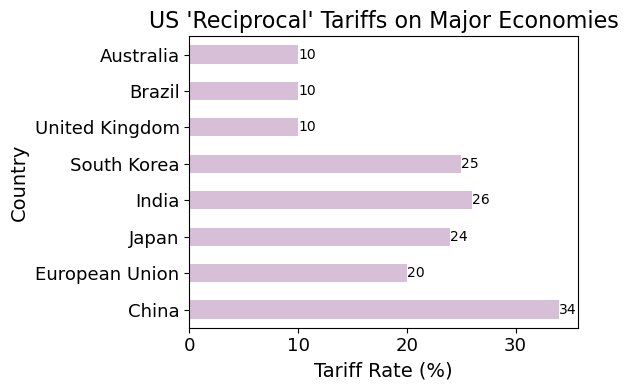

In [111]:
# Select major economies for horizontal bar plot 
major_economies = [
    'China', 'European Union', 'Japan', 'India',
    'United Kingdom', 'South Korea', 'Brazil', 'Australia', 
]

custom_df = tariff_data[
    tariff_data['Country'].isin(major_economies)
][['Country', 'U.S.A. Discounted Reciprocal Tariffs (%)']]

## Plot
ax = custom_df.plot.barh(x='Country', y='U.S.A. Discounted Reciprocal Tariffs (%)', color='thistle', figsize=(6, 4), legend=False)

# The ax.containers attribute holds the bar containers. Iterating over these containers allows you to add labels to each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.title("US 'Reciprocal' Tariffs on Major Economies", fontsize=16)
plt.ylabel('Country', fontsize=14)
plt.xlabel('Tariff Rate (%)', fontsize=14)
plt.tick_params(labelsize=13)
plt.tight_layout()
plt.show()

This subset of the dataset highlights several of the world’s most economically significant economies and the reciprocal tariff rates applied to them. China faces a 34% tariff, while the European Union is assigned a 20% rate. Other major economies such as Japan, India, and South Korea fall in the mid‑20% range. In contrast, countries like the United Kingdom, Brazil, and Australia appear at the lower end with a 10% tariff. 

### Top 20 countries hit with reciprocal tariffs

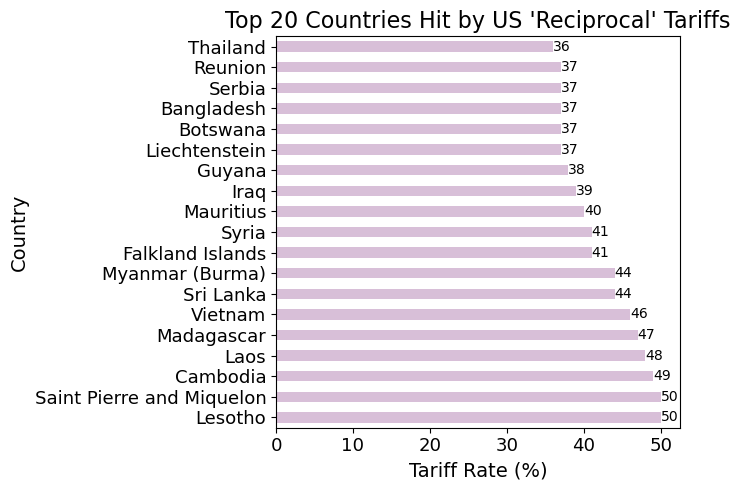

In [119]:
# Sort data in descending order of discounted reciprocal tariffs
tariff_data_sorted = tariff_data.sort_values(by='U.S.A. Discounted Reciprocal Tariffs (%)', ascending=False)

# Select top20 countries for horizontal bar plot (get rows 1-20, and columns 1 & 3)
top20_df = tariff_data_sorted.iloc[0:19,[0,2]]


## Plot
ax = top20_df.plot.barh(x='Country', y='U.S.A. Discounted Reciprocal Tariffs (%)', color='thistle', figsize=(7, 5), legend=False)

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.title("Top 20 Countries Hit by US 'Reciprocal' Tariffs", fontsize=16)
plt.ylabel('Country', fontsize=14)
plt.xlabel('Tariff Rate (%)', fontsize=14)
plt.tick_params(labelsize=13)
plt.tight_layout()
plt.show()

These countries represent the highest end of the reciprocal tariff schedule, with rates ranging from 36% to 50%. Several countries in this list are lower‑income or geopolitically complex countries. There are exceptions like Liechtenstein, a high‑income European microstate closely integrated with Switzerland.

## 6. Web Scraping Example

Just for fun!

In [125]:
# Step 1: Send a GET request to the website
URL = 'https://www.theguardian.com/us-news/2025/apr/03/donald-trump-tariffs-antarctica-uninhabited-heard-mcdonald-islands'

response = requests.get(URL)

# Checking the status code of the response
print(f"Status Code: {response.status_code}")

# If the response is successful, proceed with parsing
if response.status_code == 200:
    print(f"Successfully accessed the webpage {URL}")
else:
    print(f"Failed to access the webpage: {URL}")

Status Code: 200
Successfully accessed the webpage https://www.theguardian.com/us-news/2025/apr/03/donald-trump-tariffs-antarctica-uninhabited-heard-mcdonald-islands


In [127]:
# Step 2: Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

## Get the title
title_tag = soup.find('title')

title_tag

if title_tag:
    title = title_tag.get_text()
    # Clean the title by removing unwanted text
    # For example, removing ' | The Guardian'
    cleaned_title = title.replace(' | Trump tariffs | The Guardian', '').strip()
    print('Title:', cleaned_title)
else:
    print('No title tag found.')

Title: ‘Nowhere on Earth is safe’: Trump imposes tariffs on uninhabited islands near Antarctica


In [129]:
## Locate image by locating the <meta> tag with property='og:image'
meta_tag = soup.find('meta', property='og:image')

# Display
meta_tag

# Check if the meta tag exists and contains a 'content' attribute
if meta_tag and 'content' in meta_tag.attrs:
    image_url = meta_tag['content']
    print('Image URL:', image_url)
else:
    print('No og:image meta tag found.')

Image URL: https://i.guim.co.uk/img/media/1c1addd9f7a5f841fe692cab3154bc4d1acdb35a/0_66_1988_1193/master/1988.jpg?width=1200&height=630&quality=85&auto=format&fit=crop&precrop=40:21,offset-x50,offset-y0&overlay-align=bottom%2Cleft&overlay-width=100p&overlay-base64=L2ltZy9zdGF0aWMvb3ZlcmxheXMvdGctZGVmYXVsdC5wbmc&enable=upscale&s=f5e358569e960f9fc2091bbbb908dd78


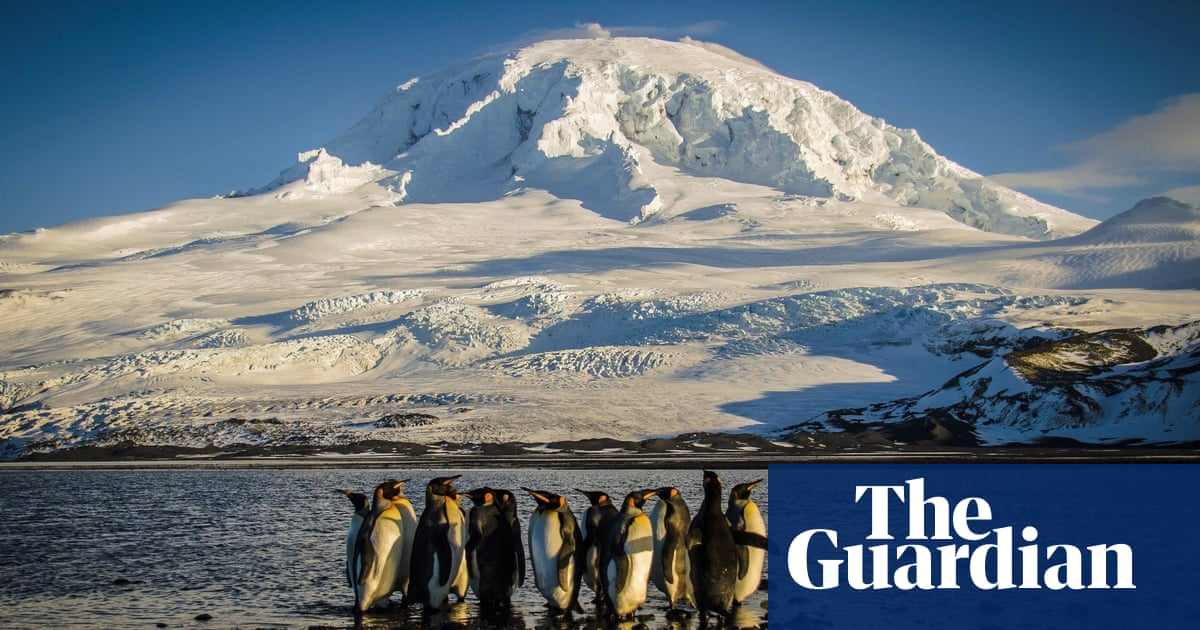

In [131]:
# Fetch the image
img_response = requests.get(image_url)

# Display the image using raw content
display(Image(img_response.content))

This image was scraped from an article from **The Guardian**, featuring *King penguins* on Heard Island. Donald Trump imposed tariffs on the *uninhabited* Heard and McDonald islands near Antarctica. 

You can check the [interactive table](#Make-an-interactive-table-using-Reactable) above to confirm this.